##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

### The model did a good job by predicting all the 20 images correctly with 100 % accuracy.


In [33]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

MODEL_ID = "facebook/dinov2-small"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 3894.58it/s]


Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

In [34]:
IMAGE_FOLDER = Path("D:\\Norah\\GitHub\\arti560-computer-vision-labs\\lab10-visual-representations\\Images")  # change if needed
def label_from_path(path):
    name = path.stem.lower()
    parent = path.parent.name.lower()

    if name.startswith("cat") or "cat" in parent:
        return "cat"
    if name.startswith("dog") or "dog" in parent:
        return "dog"

    return None  


@torch.no_grad()
def get_cls_embedding(path):
    image = Image.open(path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    cls_token = outputs.last_hidden_state[:, 0]
    return F.normalize(cls_token, p=2, dim=1).squeeze(0).cpu().numpy()


image_paths = sorted([
    p for p in IMAGE_FOLDER.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
])

cat_paths = [p for p in image_paths if label_from_path(p) == "cat"]
dog_paths = [p for p in image_paths if label_from_path(p) == "dog"]

if not cat_paths or not dog_paths:
    raise ValueError(
        f"Could not find both cat and dog images in {IMAGE_FOLDER}. "
        "Make sure filenames or folder names contain 'cat' and 'dog'."
    )


sample_size = min(10, len(cat_paths), len(dog_paths))

rng = random.Random(560)
selected_cats = sorted(rng.sample(cat_paths, sample_size))
selected_dogs = sorted(rng.sample(dog_paths, sample_size))
selected_paths = [path for pair in zip(selected_cats, selected_dogs) for path in pair]

ground_truth = np.array([0 if label_from_path(path) == "cat" else 1 for path in selected_paths])
ground_truth_names = np.where(ground_truth == 0, "cat", "dog")

embeddings = np.vstack([get_cls_embedding(path) for path in selected_paths])

print(f"Model: {MODEL_ID}")
print(f"Device: {device}")
print(f"Image folder: {IMAGE_FOLDER}")
print(f"Selected images: {len(selected_paths)}")
print(f"CLS embedding shape: {embeddings.shape}")

Model: facebook/dinov2-small
Device: cpu
Image folder: D:\Norah\GitHub\arti560-computer-vision-labs\lab10-visual-representations\Images
Selected images: 20
CLS embedding shape: (20, 384)


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=560, n_init=20)
clusters = kmeans.fit_predict(embeddings)

direct_accuracy = (clusters == ground_truth).mean()
flipped_accuracy = ((1 - clusters) == ground_truth).mean()

if flipped_accuracy > direct_accuracy:
    aligned_predictions = 1 - clusters
    accuracy = flipped_accuracy
else:
    aligned_predictions = clusters
    accuracy = direct_accuracy

predicted_species = np.where(aligned_predictions == 0, "cat", "dog")

results = pd.DataFrame(
    {
        "image": [path.name for path in selected_paths],
        "name": [path.stem for path in selected_paths],
        "ground_truth": ground_truth_names,
        "cluster_id": clusters,
        "predicted_species": predicted_species,
    }
)

display(results)
print("\nGround-truth vs. predicted species:")
display(pd.crosstab(results["ground_truth"], results["predicted_species"]))
print(f"\nClustering accuracy after label alignment: {accuracy:.2%}")




,image,name,ground_truth,cluster_id,predicted_species
0,cat1.png,cat1,cat,0,cat
1,dog1.jpg,dog1,dog,1,dog
2,cat10.jpg,cat10,cat,0,cat
3,dog10.jpg,dog10,dog,1,dog
4,cat2.png,cat2,cat,0,cat
5,dog2.jpg,dog2,dog,1,dog
6,cat3.jpg,cat3,cat,0,cat
7,dog3.jpg,dog3,dog,1,dog
8,cat4.jpg,cat4,cat,0,cat
9,dog4.jpg,dog4,dog,1,dog



Ground-truth vs. predicted species:


predicted_species,cat,dog
ground_truth,,
cat,10,0
dog,0,10



Clustering accuracy after label alignment: 100.00%


###  Exercise 2: Image Classification with DINOv2
In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:

1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:
Model ID: facebook/dinov2-small-imagenet1k-1-layer

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [39]:
import torch
import requests
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch.nn.functional as F


MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"
device = "cuda" if torch.cuda.is_available() else "cpu"


processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model {MODEL_ID} loaded on {device}")

Loading weights: 100%|██████████| 225/225 [00:00<00:00, 3008.93it/s]

Model facebook/dinov2-small-imagenet1k-1-layer loaded on cpu


In [41]:
# Define the precise local path to your image
image_path = r"D:\Norah\GitHub\arti560-computer-vision-labs\lab10-visual-representations\Flamingo.jpg"

# Initialize variable to track success
img = None

try:
    img = Image.open(image_path).convert("RGB")
    print("Image loaded successfully!")
except Exception as e:
    print(f"Error loading image: {e}")
    print("Please check that the file exists and the path is completely correct.")

Image loaded successfully!


Model: facebook/dinov2-small-imagenet1k-1-layer
Device: cpu
Image path: D:\Norah\GitHub\arti560-computer-vision-labs\lab10-visual-representations\Flamingo.jpg
CLS embedding shape: (1, 384)
First 10 embedding values: [-0.046917639672756195, 0.03978429362177849, 0.056843776255846024, -0.06880496442317963, -0.03240254893898964, 0.011873342096805573, 0.09260667115449905, 0.0690828263759613, 0.02464999072253704, -0.002871996257454157]

Top-5 ImageNet-1k predictions:
1. flamingo: 0.9998 (99.98%)
2. crane: 0.0001 (0.01%)
3. little blue heron, Egretta caerulea: 0.0000 (0.00%)
4. goldfish, Carassius auratus: 0.0000 (0.00%)
5. black swan, Cygnus atratus: 0.0000 (0.00%)


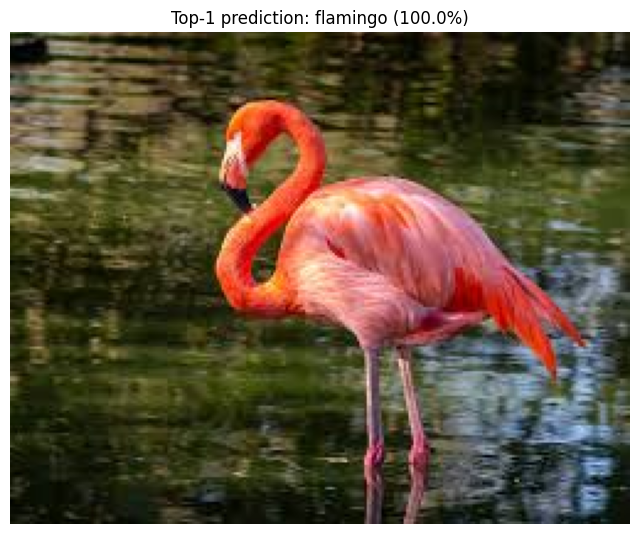

In [43]:
inputs = processor(images=img, return_tensors="pt").to(device)

with torch.no_grad():
    backbone_outputs = model.dinov2(**inputs)
    cls_embedding = backbone_outputs.last_hidden_state[:, 0]
    cls_embedding = F.normalize(cls_embedding, p=2, dim=1)

    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, k=5, dim=-1)

print(f"Model: {MODEL_ID}")
print(f"Device: {device}")
print(f"Image path: {image_path}")
print(f"CLS embedding shape: {tuple(cls_embedding.shape)}")
print(f"First 10 embedding values: {cls_embedding[0, :10].cpu().tolist()}\n")
print("Top-5 ImageNet-1k predictions:")

for rank, (idx, score) in enumerate(zip(top_indices[0].tolist(), top_probs[0].tolist()), start=1):
    label = model.config.id2label[idx]
    print(f"{rank}. {label}: {score:.4f} ({score * 100:.2f}%)")

top_idx = top_indices[0, 0].item()
top_label = model.config.id2label[top_idx]
top_score = top_probs[0, 0].item()

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"Top-1 prediction: {top_label} ({top_score * 100:.1f}%)")
plt.axis("off")
plt.show()

### The model did a wonderful job by classifying the image correctly (Flamingo) with high confidence reaching to 100%